## This notebook is for training and testing the model

### Why XGBoost:

1. works very well on tabular data
2. handles nonlinear relationships
3. needs less data than neural networks
4. interpretable with feature importance
5. fast to train
6. strong baseline for pricing problems

In [54]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    mean_absolute_percentage_error,
    median_absolute_error,
)


In [55]:
df = pd.read_csv("processed_datasets/pricing_training_table.csv")

target = "revenue_aud"

# remove the all the rows where the load_type is Refrigerated
df = df[df["load_type"] != "Refrigerated"]
# fuel_surcharge_rate,actual_duration_hours,weight_kg,distance_km,fuel_quantity_liters,avg_fuel_price_aud_per_liter,total_fuel_cost_aud,revenue_aud,fuel_surcharge_aud,base_rate_per_km_aud
drop_cols = [
    target,
    "load_type",
    "origin_city",
    "destination_city",
    "lane",
    "base_rate_per_mile",
    "pieces",
    "fuel_surcharge",
    "total_fuel_quantity",
    "annual_revenue_potential_aud",
    "primary_freight_type",
]


drop_cols.extend(
    [
        "fuel_surcharge_rate",
        "actual_duration_hours",
        #"weight_kg",
        "fuel_quantity_liters",
        "avg_fuel_price_aud_per_liter",
        "total_fuel_cost_aud",
        "fuel_surcharge_aud",
        "base_rate_per_km_aud",
    ]
)


feature_cols = [c for c in df.columns if c not in drop_cols]

print("Features:", feature_cols)

X = df[feature_cols].copy()
y = df[target].copy()


# datetime-Spalten raus
for c in X.columns:
    if str(X[c].dtype).startswith("datetime"):
        X = X.drop(columns=[c])

# categorical -> category codes
for c in X.columns:
    if X[c].dtype == "string" or X[c].dtype == "object":
        X[c] = X[c].astype("category")

cat_cols = X.select_dtypes(include=["category"]).columns.tolist()
for c in cat_cols:
    X[c] = X[c].cat.codes.replace(-1, np.nan)

# simple fillna
for c in X.columns:
    if X[c].dtype.kind in "biufc":
        X[c] = X[c].fillna(X[c].median())
    else:
        X[c] = X[c].fillna("missing")

Features: ['weight_kg', 'distance_km']


In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 1. Initialize the base model
base_model = XGBRegressor(random_state=42, n_jobs=-1)

# 2. Define the grid of parameters you want to test
param_distributions = {
    "n_estimators": [100, 300, 500, 700],
    "max_depth": [3, 5, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
}

# 3. Set up the randomized search
# n_iter=20 means it will randomly test 20 different combinations.
# cv=3 means 3-fold cross-validation (helps prevent overfitting).
search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="neg_mean_absolute_error",  # We want to minimize MAE
    cv=3,
    verbose=1,  # Prints the progress in your console
    random_state=42,
    n_jobs=-1,
)

print("Starting hyperparameter tuning...")

# 4. Fit the search on the training data
search.fit(X_train, y_train)

# 5. Print the winning combination
print("\nBest parameters found:")
print(search.best_params_)

# 6. Extract the best model from the search
best_model = search.best_estimator_

# 7. Evaluate the winning model on your holdout test set
pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("\n--- Final Test Set Performance ---")
print("MAE:", mae)
print("RMSE:", rmse)

# 8. Save the best model to disk for your backend
best_model.save_model("xgboost_pricing_model.json")
print("\nSuccess: Best model saved as 'xgboost_pricing_model.json'")

Starting hyperparameter tuning...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best parameters found:
{'subsample': 1.0, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

--- Final Test Set Performance ---
MAE: 447.6324977311566
RMSE: 622.7137144886397

Success: Best model saved as 'xgboost_pricing_model.json'


R2 Score: 0.9668
MAPE: 0.0870
Median Absolute Error: 306.7839


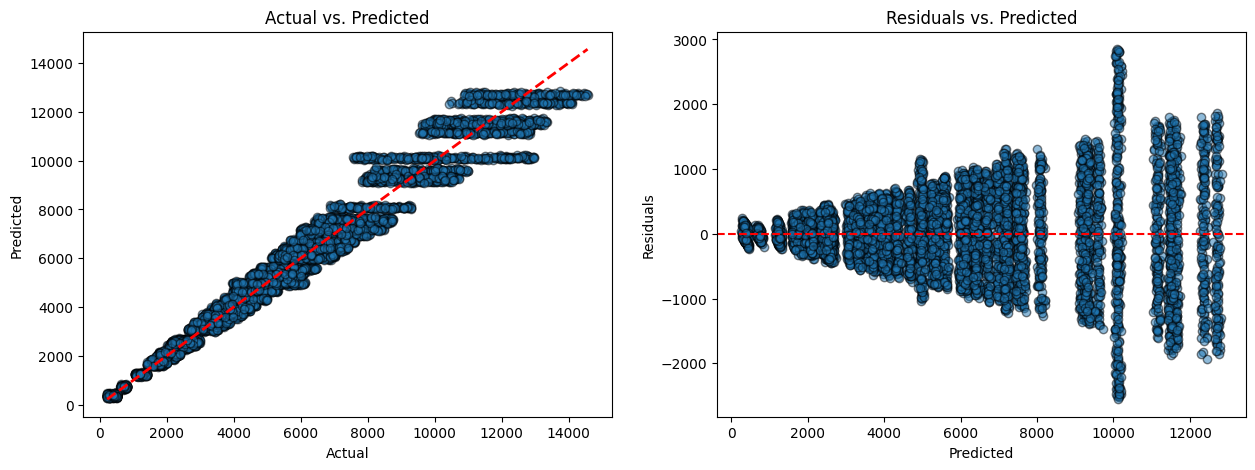

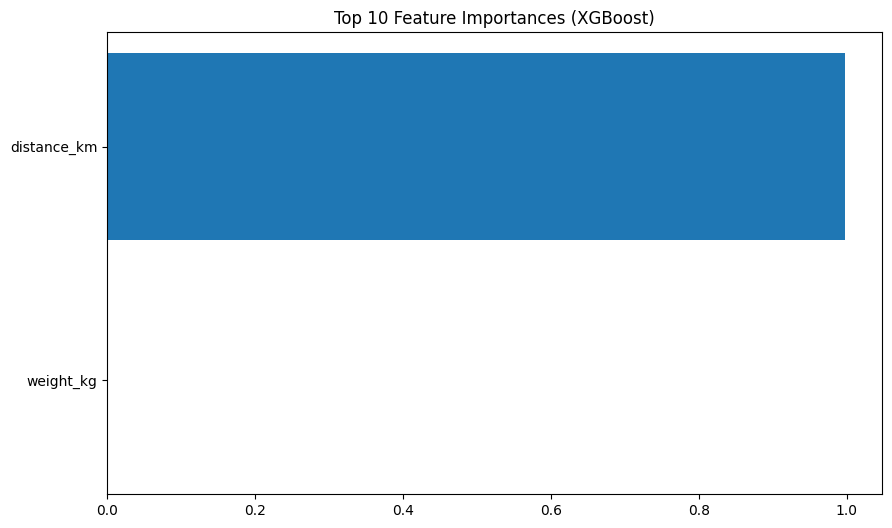

In [57]:
# 1. Calculate Additional Metrics
r2 = r2_score(y_test, pred)
mape = mean_absolute_percentage_error(y_test, pred)
medae = median_absolute_error(y_test, pred)

print(f"R2 Score: {r2:.4f}")
print(f"MAPE: {mape:.4f}")
print(f"Median Absolute Error: {medae:.4f}")

# 2. Visualizing Performance
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Actual vs Predicted
ax[0].scatter(y_test, pred, alpha=0.5, edgecolors="k")
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
ax[0].set_title("Actual vs. Predicted")
ax[0].set_xlabel("Actual")
ax[0].set_ylabel("Predicted")

# Residual Plot
residuals = y_test - pred
ax[1].scatter(pred, residuals, alpha=0.5, edgecolors="k")
ax[1].axhline(0, color="r", linestyle="--")
ax[1].set_title("Residuals vs. Predicted")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Residuals")

plt.show()

# 3. Feature Importance
plt.figure(figsize=(10, 6))
importances = best_model.feature_importances_
indices = np.argsort(importances)[-10:]  # Top 10 features
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title("Top 10 Feature Importances (XGBoost)")
plt.show()

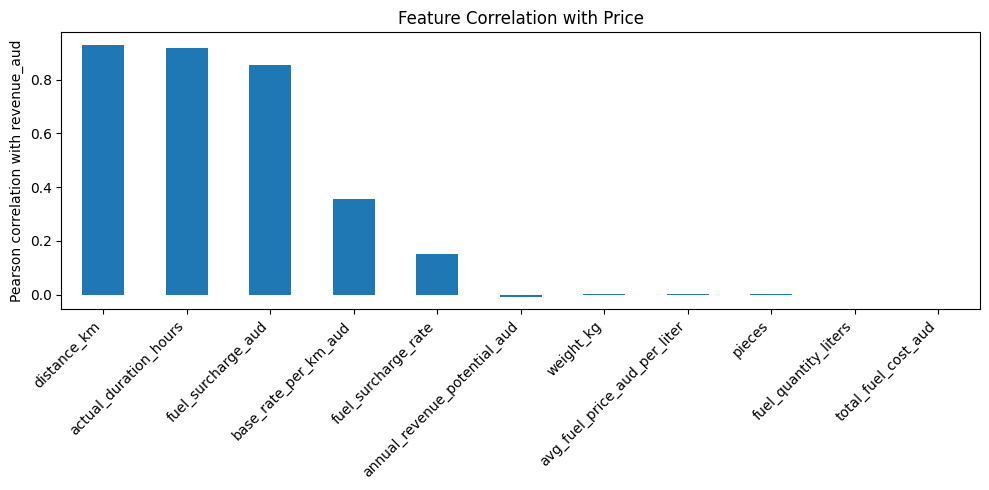

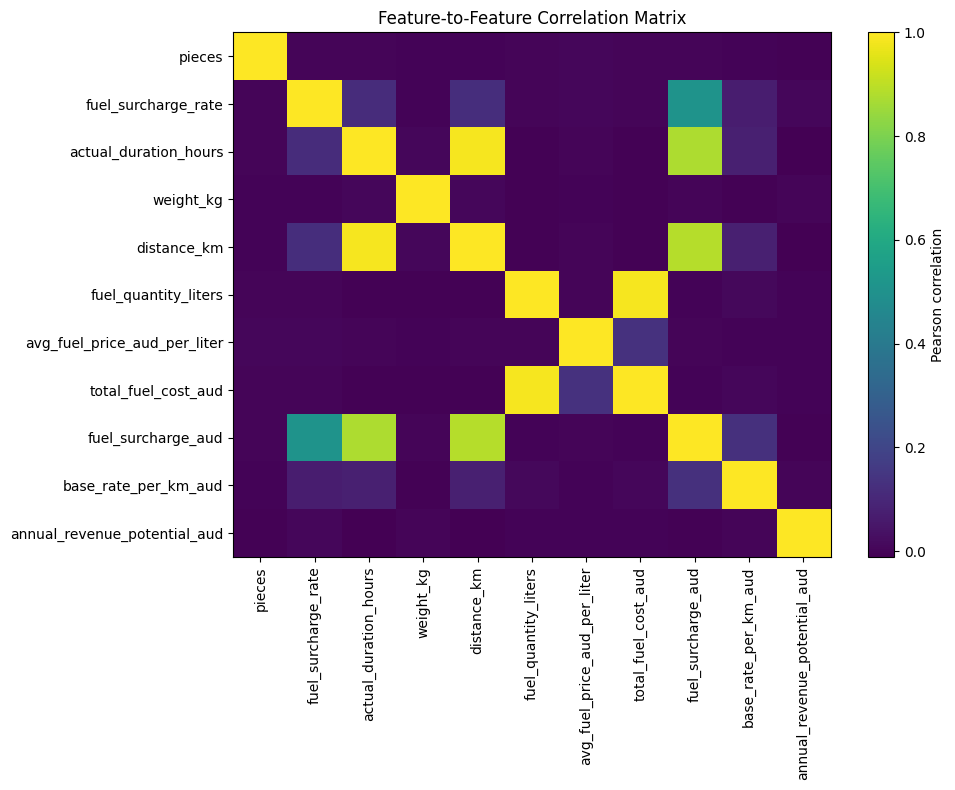

In [58]:
# df = your dataframe
target = "revenue_aud"

numeric_cols = df.select_dtypes(include="number").columns.tolist()

# -----------------------------
# 1) Correlation: features vs price
# -----------------------------
price_corr = (
    df[numeric_cols]
    .corr()[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
)

plt.figure(figsize=(10, 5))
price_corr.plot(kind="bar")
plt.title("Feature Correlation with Price")
plt.ylabel("Pearson correlation with revenue_aud")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# -----------------------------
# 2) Correlation: features with each other
# -----------------------------
feature_corr = df[numeric_cols].drop(columns=[target]).corr()

plt.figure(figsize=(10, 8))
plt.imshow(feature_corr, aspect="auto")
plt.colorbar(label="Pearson correlation")
plt.xticks(range(len(feature_corr.columns)), feature_corr.columns, rotation=90)
plt.yticks(range(len(feature_corr.columns)), feature_corr.columns)
plt.title("Feature-to-Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [59]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, max_depth=None, random_state=42, n_jobs=-1
    ),
    "Simple Neural Network": MLPRegressor(
        hidden_layer_sizes=(64, 32), activation="relu", max_iter=1000, random_state=42
    ),
}

results = []

for name, model in models.items():
    print(f"Training {name}...")

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append({"model": name, "MAE": mae, "RMSE": rmse, "R2": r2})

results_df = pd.DataFrame(results).sort_values("MAE")
print(results_df)

Training Linear Regression...
Training Random Forest...
Training Simple Neural Network...
                   model         MAE         RMSE        R2
1          Random Forest  514.665594   748.062514  0.952154
2  Simple Neural Network  893.553808  1262.214482  0.863782
0      Linear Regression  899.227706  1263.538159  0.863496
